## 6.S083 / 18.S190
# PSET 3 Solution – Epidemic Outbreaks

#### Author: Dan Segal (@[djsegal](https://github.com/djsegal))

In [1]:
# import Pkg

# Pkg.add("LsqFit")
# Pkg.add("Statistics")
# Pkg.add("StatsBase")


## Exercise 1: Rumor Modeling

In this exercise we will model the spread of an infection or rumour in which
+ there is no recovery via a stochastic model
+ we will implement in a Monte Carlo simulation


### 1. Julia has a data type called an [**enumerated type**](https://en.wikipedia.org/wiki/Enumerated_type)

+ Variables of this type can only take one of a pre-defined set of values
+ we will use this to model the possible internal state of an agent.


In [2]:
@enum InfectionStatus S I R
x = S

@assert typeof(x) == InfectionStatus


### 2. Convert `x` to an integer using the `Int` function
+ What value does it have? 
+ What values do `I` and `R` have?


In [3]:
@assert Int(x) == 0

@assert Int(I) == 1
@assert Int(R) == 2

@assert Int(x) == Int(S)


### 3. Make an array `agents` whose $i$th entry is the status of agent number $i$
+ Take $N=100$
+ Make them all initially susceptible


In [4]:
N = 100
make_agents(N) = [ S for _ in 1:N ]
agents = make_agents(N)

@assert sum(map(Int,agents)) == 0


### 4. Now choose a single agent at random and make it infectious
+ Use the `rand` function with a range to choose the index of the infectious agent



In [5]:
unlucky_index = rand(1:N)
agents[unlucky_index] = I

@assert sum(map(Int,agents)) == 1


### 5. Write a function `step!` 
+ that takes a `Vector` `agents` and a probability `p_I` as arguments  
+ This function may *modify* the content of `agents` to implement one step of the infection dynamics


In [6]:
function step!(agents::Vector, p_I::Number)
  N = length(agents)
  
  # Choose an agent at random
  i = rand(1:N)
  
  # If i is not infectious then nothing happens
  ( agents[i] != I ) && return
  
  # Choose another agent at random
  j = rand(1:N)
  while i == j
    j = rand(1:N)
  end
  
  # Infect j with probability p_I
  ( rand() < p_I ) || return
  agents[j] = I
end

step! (generic function with 1 method)

### 6. Write a function `sweep!`
+ It runs `step!` $N$ times 
+ One sweep is thus the unit of time in our Monte Carlo simulation


In [7]:
sweep!(agents::Vector, p_I::Number) = [ step!(agents, p_I) for _ in 1:length(agents) ]

sweep! (generic function with 1 method)

### 7. Write a function `infection_simulation`
+ it should take $N$ and $p_I$ as arguments
+ as well as $T$, the total number of steps


In [8]:
function infection_simulation(N::Int, p_I::Number, T::Int)
  # Make agents
  agents = make_agents(N)
  agents[rand(1:N)] = I
  
  # Make infectious counter
  Is = zeros(Int, T)
  
  # Run sweep! T times and bookkeep in Is
  for t in 1:T
    sweep!(agents, p_I)
    Is[t] = sum(map(Int, agents))
  end
  
  # Return Is as output
  Is
end


infection_simulation (generic function with 1 method)

### 8. Run your simulation 50 times with $N=100$ 
+ collect the data in a `Vector` of `Vector`s called `results`
+ plot each using $p_I = 0.02$ and $T = 1000$


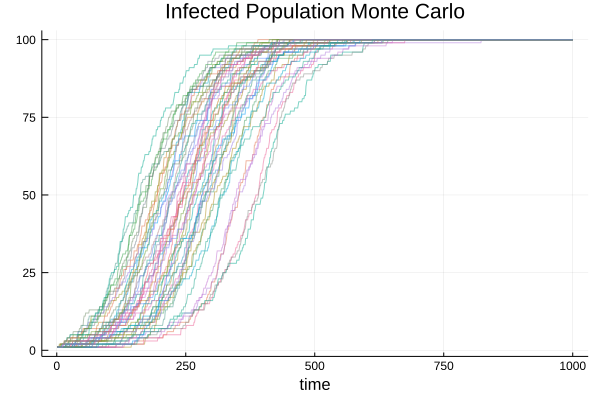

In [9]:
using Plots

N = 100
p_I = 0.02
T = 1000

results = []
for i in 1:50
  push!(results, infection_simulation(N, p_I, T))
end

monte_carlo_plot(results) = plot(
  results, label="", alpha=0.5,
  xlabel="time", title="Infected Population Monte Carlo"
)

monte_carlo_plot(results)


### 9. Calculate the mean trajectory using the `mean` function applied to `results`


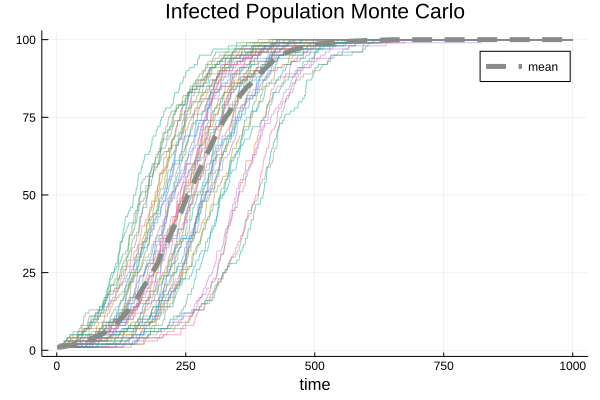

In [10]:
using StatsBase

monte_carlo_plot(results)
plot!(mean(results), linewidth=5, linestyle=:dash, label="mean")


### 10. Calculate the standard deviation $\sigma$ of $I$ at each step


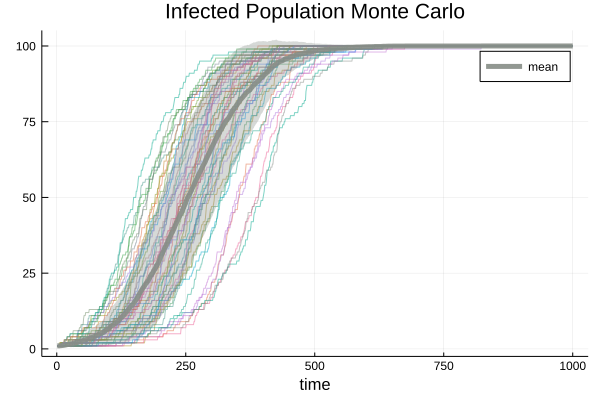

In [11]:
using Statistics

function monte_carlo_plot_complete(results)
  monte_carlo_plot(results)

  plot!(
    mean(results), ribbon=std(results), label="mean", 
    linewidth=5, fillalpha=1/3, linealpha=0.9
  )
end

monte_carlo_plot_complete(results)

In [12]:
using Interact

linspace(a,b,n) = range(a,stop=b,length=n)
logspace(a::Int,b::Int,n) = map(Int,map(round, 10 .^ linspace(log10(a),log10(b),n)))
logspace(a,b,n) = 10 .^ linspace(log10(a),log10(b),n)

@manipulate for p_I in 0.1:0.2:0.9, T=logspace(10, 10^3, 5), N=logspace(10, 10^3, 5)
  tmp_results = []
  for i in 1:50
    push!(tmp_results, infection_simulation(N, p_I, T))
  end

  monte_carlo_plot_complete(tmp_results)
end

HTML{String}("<script>\n// Immediately-invoked-function-expression to avoid global variables.\n(function() {\n    var warning_div = document.getElementById(\"webio-warning-9302040987646783158\");\n    var hide = function () {\n        var script = document.getElementById(\"webio-setup-12628560650336258086\");\n        var parent = script && script.parentElement;\n        var grandparent = parent && parent.parentElement;\n        if (grandparent) {\n            grandparent.style.display = \"none\";\n        }\n        warning_div.style.display = \"none\";\n    };\n    if (typeof Jupyter !== \"undefined\") {\n        console.log(\"WebIO detected Jupyter notebook environment.\");\n        // Jupyter notebook.\n        var extensions = (\n            Jupyter\n            && Jupyter.notebook.config.data\n            && Jupyter.notebook.config.data.load_extensions\n        );\n        if (extensions && extensions[\"webio-jupyter-notebook\"]) {\n            // Extension already loaded.\n            console.log(\"Jupyter WebIO nbextension detected; not loading ad-hoc.\");\n            hide();\n            return;\n        }\n    } else if (window.location.pathname.includes(\"/lab\")) {\n        // Guessing JupyterLa\n        console.log(\"Jupyter Lab detected; make sure the @webio/jupyter-lab-provider labextension is installed.\");\n        hide();\n        return;\n    }\n})();\n\n</script>\n<p\n    id=\"webio-warning-9302040987646783158\"\n    class=\"output_text output_stderr\"\n    style=\"padding: 1em; font-weight: bold;\"\n>\n    Unable to load WebIO. Please make sure WebIO works for your Jupyter client.\n    For troubleshooting, please see <a href=\"https://juliagizmos.github.io/WebIO.jl/latest/providers/ijulia/\">\n    the WebIO/IJulia documentation</a>.\n    <!-- TODO: link to installation docs. -->\n</p>\n")

Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["p_I"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 5,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Any} with 2 listeners. Value:
3, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x000000011a250010, Task (runnable) @0x000000011a250010), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0.1\",\"0.3\",\"0.5\",\"0.7\",\"0.9\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"3214098891081543331\",\"id\":\"3378849897222454212\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"name\":\"index\",\"scope\":\"3214098891081543331\",\"id

### 11. You should see that the mean behaves similarly to last week's *deterministic* model

#### Q: So what is the deterministic model possibly describing, in terms of the stochastic model?

#### A: The average or expected case – i.e. the one with the highest likelihood of occuring

----

## Exercise 2: Agent type

Suppose we want to track more information about each agent

// e.g. how many other agents were infected by that agent


### 1. Define a mutable type `Agent` as follows:


In [13]:
mutable struct Agent
  status::InfectionStatus
  num_infected::Int
end


### 2. Define a method of the constructor of `Agent` 
+ that takes no arguments 
+ sets the status to `S` and the number infected to 0


In [14]:
Agent() = Agent(S, 0)

@assert Agent().status == S
@assert Agent().num_infected == 0


In [15]:
N = 100
make_agents_new(N) = [ Agent() for _ in 1:N ]

agents = make_agents_new(N)
agents[1].status = I

@assert sum(map((agent) -> Int(agent.status), agents)) == 1
@assert sum(map((agent) -> Int(agent.num_infected), agents)) == 0



### 3. Rewrite your code from Exercise 1 to use the new `Agent` type
+ Now when your functions accept an `agents` vector, 
+ they should assume that that represents a `Vector` of `Agent` objects


In [16]:
# sweep! just works (TM)

function step!(agents::Vector{Agent}, p_I::Number)
  N = length(agents)
  
  # Choose an agent at random
  i = rand(1:N)
  agent = agents[i]
  
  # If i is not infectious then nothing happens
  ( agent.status == I ) || return agent
  
  # Choose another agent at random
  j = rand(1:N)
  while i == j
    j = rand(1:N)
  end
  
  # Only infect susceptible people
  other_agent = agents[j]
  ( other_agent.status == S ) || return agent
  
  # Infect j with probability p_I
  ( rand() < p_I ) && infect!(agent, other_agent)
  
  agent
end


step! (generic function with 2 methods)

### 4. Update an agent's `num_infected` field whenever it infects another agent.


In [17]:
# infect! used inside step! function just above this

function infect!(infected::Agent, susceptible::Agent)
  @assert infected.status == I
  @assert susceptible.status == S
  
  infected.num_infected +=1
  susceptible.status = I
end


infect! (generic function with 1 method)

### 5. At the end of the simulation, extract the probability distribution of the "number of agents infected", using your code from Exercise 1 of Problem Set 2.


In [18]:
# this is a method we built last week!

function counts(data::Vector)
  d = Dict{Int, Int}()
  
  for cur_value in data
    if haskey(d, cur_value)
      d[cur_value] += 1
    else
      d[cur_value] = 1
    end
  end
  
  return d
end

function sorted_counts(data::Vector)
  cc = counts(data)
  ks = collect(keys(cc))
  vs = collect(values(cc))
  
  p = sortperm(ks)
  ks .= ks[p]
  vs .= vs[p]
  
  return (ks, vs)
end

function probability_distribution(data::Vector)
  (ks, vs) = sorted_counts(data)
  
  # implicitly casts as floats
  vs = vs / sum(vs)
  
  return (ks, vs)
end


probability_distribution (generic function with 1 method)

In [19]:
function num_infected_dist_simulation(N::Int, p_I::Number, T::Int)
  agents = make_agents_new(N)
  agents[1].status = I
  
  [ sweep!(agents, p_I) for _ in 1:T ]
  infected_counts = map((agent) -> agent.num_infected, agents)
  
  probability_distribution(infected_counts)
end


num_infected_dist_simulation (generic function with 1 method)

### 6. Plot the probability distribution

+ What kind of distribution does it seem to be? 
+ You will need to think about how to visualize this

#### A: The distribution appears to be geometric (as it was in pset 2)

In [20]:
macro run_50_times(cur_code)

  distribution_dict = DefaultDict(Vector)

  for _ in 1:50
    tmp_distribution = eval(cur_code)

    for (cur_key, cur_value) in zip(tmp_distribution...)
      push!(distribution_dict[cur_key], cur_value)
    end
  end

  cur_x, cur_y = [], []

  for cur_key in sort(collect(keys(distribution_dict)))
    push!(cur_x, 1+cur_key)  
    push!(cur_y, sum(distribution_dict[cur_key])/50)
  end
  
  return (cur_x, cur_y)

end

@run_50_times (macro with 1 method)

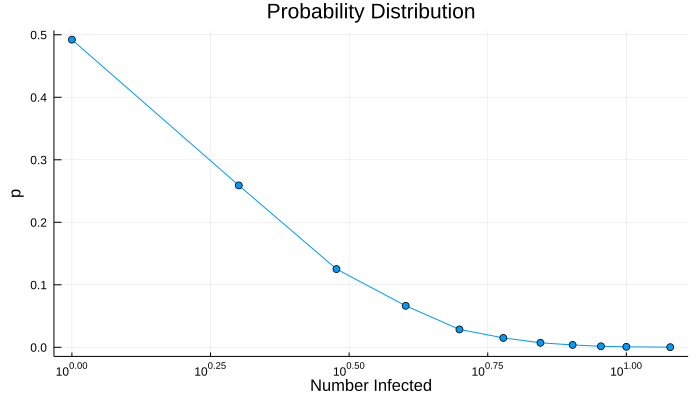

In [21]:
using DataStructures

N_new = 100
p_I_new = 0.02
T_new = 1000

cur_distribution = @run_50_times num_infected_dist_simulation(N_new, p_I_new, T_new)

plot(
  cur_distribution, title="Probability Distribution",
  xlabel="Number Infected", ylabel="p", label="",
  size=(700,400), xscale=:log10, markershape=:circle
)


----

## Exercise 3: Epidemic model

### 1. Add recovery to your model 
+ using an additional parameter `p_R` in the `step!` and related functions
+ Each agent should check if it is infected, and if so it recovers with probability $p_R$ at each step.


In [22]:
function step!(agents::Vector{Agent}, p_I::Number, p_R::Number)
  agent = step!(agents, p_I::Number)
  ( agent.status == I ) || return 
  
  ( rand() < p_R ) || return
  agent.status = R
end

sweep!(agents::Vector, p_I::Number, p_R::Number) = [ step!(agents, p_I, p_R) for _ in 1:length(agents) ]


sweep! (generic function with 2 methods)

### 2. Define and run a new simulation 

+ with $N=1000$, $p_I = 0.1$ and $p_R = 0.01$ for time $T=1000$
+ Plot $S$, $I$ and $R$ as a function of time


In [23]:
function simulation_with_recovery(N::Int, p_I::Number, p_R::Number, T::Int)
  
  agents = make_agents_new(N)
  agents[1].status = I
  
  Ss, Is, Rs = [ zeros(Int, T) for _ in 1:3 ]
  
  for t in 1:T
    sweep!(agents, p_I, p_R)
      
    Ss[t] = count((agent) -> agent.status == S, agents)
    Is[t] = count((agent) -> agent.status == I, agents)
    Rs[t] = count((agent) -> agent.status == R, agents)
  end
    
  infected_counts = map((agent) -> agent.num_infected, agents)
  cur_distribution = probability_distribution(infected_counts)
  
  return Ss, Is, Rs, cur_distribution
  
end


simulation_with_recovery (generic function with 1 method)

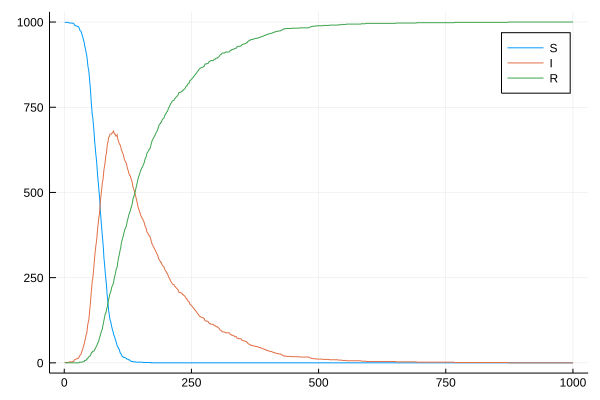

In [24]:
N_SIR = 1000
T_SIR = 1000

p_I_SIR = 0.1
p_R_SIR = 0.01

Ss, Is, Rs, cur_distribution = nothing, nothing, nothing, nothing

while isnothing(Rs) || maximum(Rs) < N_SIR / 10
  Ss, Is, Rs, cur_distribution = simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)
end

plot([Ss, Is, Rs], label=["S" "I" "R"])

### 3. Plot the distribution of `num_infected`. Does it have a recognisable shape?

#### A: Geometric as before in problem 2.6

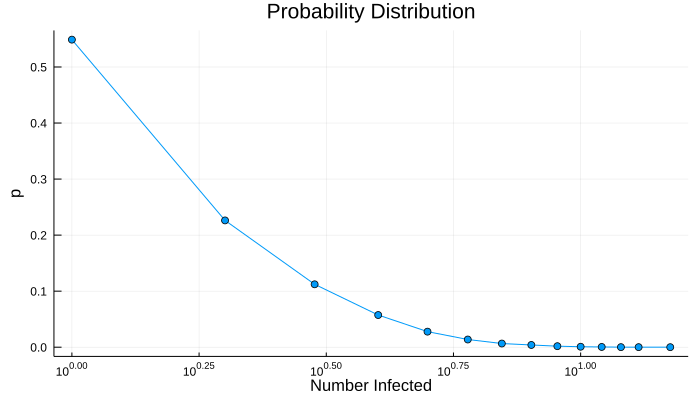

In [25]:
cur_distribution = @run_50_times simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)[4]

plot(
  cur_distribution, title="Probability Distribution",
  xlabel="Number Infected", ylabel="p", label="",
  size=(700,400), xscale=:log10, markershape=:circle
)

### 4. Run the simulation 50 times and plot $I$ as a function of time for each
+ together with the mean over the 50 simulations (as you did in Exercise 2)


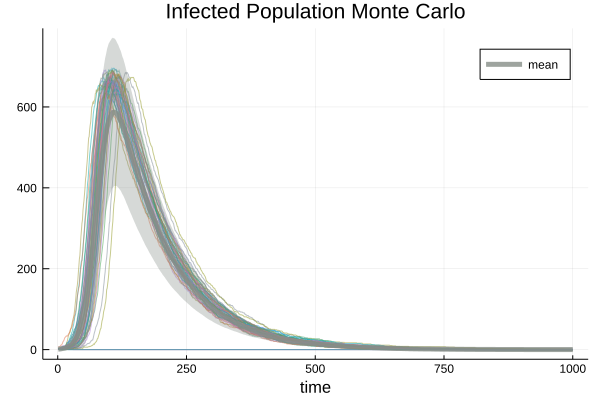

In [26]:
results = []
for i in 1:50
  push!(results, simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)[2])
end

plot(
  results, label="", alpha=0.5,
  xlabel="time", title="Infected Population Monte Carlo"
)

plot!(
  mean(results), ribbon=std(results), label="mean", 
  linewidth=5, fillalpha=1/3, linealpha=0.8
)


### 5. Describe 3 ways in which you could characterize the magnitude of the epidemic

+ Find these quantities for one of the runs of your simulation


#### A. Peak Infected



In [27]:
Ss, Is, Rs, cur_distribution = simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)

I_peak(Is) = findmax(Is)

I_peak(Is)

(705, 122)

#### B. The I-R Intersection

In [28]:
Ss, Is, Rs, cur_distribution = simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)

function I_R_intersect(Is, Rs) 
  _, cur_index = findmin( ( 1 .+ abs.( Is - Rs ) ) ./ ( Is .+ Rs ) )
  
  cur_value = Is[cur_index]
  cur_value += Rs[cur_index]
  cur_value /= 2
  
  return (cur_value, cur_index)
end

I_R_intersect(Is, Rs) 

(0.5, 1)

#### C. Recovered Inflection 

In [29]:
using LsqFit

@. model(x, p) = p[1] * exp( -p[2] * exp( -p[3] * exp( -p[4] * x ) ) )

function smooth_data(cur_data)
  xx = map(Float64, 1:length(cur_data))
  max_value = maximum(cur_data)
  
  cur_fit = curve_fit(model, xx, cur_data, [max_value,log(2),1,1])
  
  yy = model.(xx, Ref(cur_fit.param))
  
  yy
end


smooth_data (generic function with 1 method)

In [30]:
Ss, Is, Rs, cur_distribution = simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)

function R_inflection(Rs) 
  custom_inflection = 1 ./ abs.(diff(diff(smooth_data(Rs))))
  
  custom_inflection .*= mean.(zip(
    abs.(diff(smooth_data(Rs)[1:end-1])),
    abs.(diff(smooth_data(Rs)[2:end]))
  ))
  custom_inflection ./= abs.(smooth_data(Rs)[2:end-1])
  custom_inflection .*= (1:length(custom_inflection)) .^ (1/8)

  _, cur_index = findmin(custom_inflection)
  
  cur_index += 1
  
  cur_value = Rs[cur_index]
  return (cur_value, cur_index)
end

R_inflection(Rs) 

(827, 269)

#### D. Plotting 3 Quantities

In [31]:
function make_quantities_plot(N_SIR, p_I_SIR, p_R_SIR, T_SIR)
  Ss, Is, Rs, cur_distribution = nothing, nothing, nothing, nothing

  while isnothing(Rs) || maximum(Rs) < N_SIR / 10
    Ss, Is, Rs, cur_distribution = simulation_with_recovery(N_SIR, p_I_SIR, p_R_SIR, T_SIR)
  end

  plot([Ss, Is], label=["S" "I"], title="SIR Model with Key Features")

  plot!(smooth_data(Rs), label="R (fit)", alpha=0.5, linestyle=:dash, linewidth=2)
  plot!(Rs, label="R (actual)")

  xlabel!("time")
  ylabel!("N")

  annotate!(reverse(I_peak(Is))..., "A")
  annotate!(reverse(I_R_intersect(Is, Rs))..., "B")
  annotate!(reverse(R_inflection(Rs))..., "C")
end

make_quantities_plot (generic function with 1 method)

In [33]:
p_I_slider = slider(logspace(p_I_SIR/2,p_I_SIR*2,3), value=p_I_SIR, label="p_I")
p_R_slider = slider(logspace(p_R_SIR/2,p_R_SIR*2,3), value=p_R_SIR, label="p_R")

N_slider = slider(logspace(Int(N_SIR/5),Int(N_SIR*5),3), value=N_SIR, label="N")
T_slider = slider(logspace(Int(T_SIR/5),Int(T_SIR*5),3), value=T_SIR, label="T")

@manipulate for p_I=p_I_slider, p_R=p_R_slider, N=N_slider, T=T_slider
  make_quantities_plot(N, p_I, p_R, T)
end


Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["p_I"], Dict{Symbol,Any}(:className => "interact ",:style => Dict{Any,Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol,Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol,Any}(:max => 3,:min => 1,:attributes => Dict{Any,Any}(:type => "range",Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}","orient" => "horizontal"),:step => 1,:className => "slider slider is-fullwidth",:style => Dict{Any,Any}()))], Dict{Symbol,Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol,Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol,Any}(:className => "interact-flex-row-right"))], Dict{Symbol,Any}(:className => "interact-flex-row interact-widget")), Dict{String,Tuple{Observables.AbstractObservable,Union{Nothing, Bool}}}("changes" => (Observable{Int64} with 1 listeners. Value:
0, nothing),"index" => (Observable{Any} with 2 listeners. Value:
2, nothing)), Set(String[]), nothing, Asset[Asset("js", "knockout", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout.js"), Asset("js", "knockout_punches", "/Users/dan/.julia/packages/Knockout/IP1uR/src/../assets/knockout_punches.js"), Asset("js", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/all.js"), Asset("css", nothing, "/Users/dan/.julia/packages/InteractBase/NMcus/src/../assets/style.css"), Asset("css", nothing, "/Users/dan/.julia/packages/Interact/SbgIk/src/../assets/bulma_confined.min.css")], Dict{Any,Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")],"index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(sz_max:32,sz_curr:0), Set(AbstractConnection[]), Base.GenericCondition{Base.AlwaysLockedST}(Base.InvasiveLinkedList{Task}(Task (runnable) @0x0000000117d21f90, Task (runnable) @0x0000000117d21f90), Base.AlwaysLockedST(1))), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"0.05\",\"0.1\",\"0.2\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"14721648919708100201\",\"id\":\"9390446752230012046\",\"type\":\"observable\"}),\"index\":WebIO.getval({\"name\":\"index\",\"scope\":\"14721648919708100201\",\"id\":\"14228933

----

## Extra Credit: Web Dashboard

In [ ]:
# load file with custom plot extractor

include("dont_manipulate.jl")


In [ ]:
plotlyjs()

@dont_manipulate "../docs/assets/json/monte-carlo.json" for N=logspace(10, 10^3, 5), p_I in 0.1:0.2:0.9, T=logspace(10, 10^3, 5)
  tmp_results = []
  for i in 1:50
    push!(tmp_results, infection_simulation(N, p_I, T))
  end

  monte_carlo_plot_complete(tmp_results)
end

@dont_manipulate "../docs/assets/json/sir-model.json" for N=N_slider, p_I=p_I_slider, p_R=p_R_slider, T=T_slider
  make_quantities_plot(N, p_I, p_R, T)
end

gr()